In [1]:
# write the list of necessary packages here:
!pip install pandas
!pip install nltk
!pip install spacy
!pip install scikit-learn
!pip install sklearn-crfsuite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.5 MB/s eta 0:00:00


## Training a model on Named Entity Recognition task

Token classification refers to the task of classifying individual tokens in a sentence. One of the most common token
classification tasks is Named Entity Recognition (NER). NER attempts to find a label for each entity in a sentence,
such as a person, location, or organization. In this assignment, you will learn how to train a model on the [CoNLL 2023 NER Dataset](https://www.clips.uantwerpen.be/conll2003/ner/) dataset to detect new entities.

### Loading the dataset

In [9]:
# import your packages here:
import pandas as pd
import nltk
from sklearn_crfsuite import CRF, metrics



In [15]:
train_df = pd.read_csv("ner_data/train.txt", header=0, sep=" ")
train_df.columns = ["token", "pos", "chunk", "ne"]


val_df = pd.read_csv("ner_data/val.txt", header=0, sep=" ")
val_df.columns = ["token", "pos", "chunk", "ne"]


test_df = pd.read_csv("ner_data/test.txt", header=0, sep=" ")
test_df.columns = ["token", "pos", "chunk", "ne"]


print(f"{train_df.shape}, {val_df.shape}, {test_df.shape}")

tag_distribution = train_df.groupby("ne").size().reset_index(name='counts')
print(tag_distribution)

(204566, 4), (51577, 4), (46665, 4)
       ne  counts
0   B-LOC    7140
1  B-MISC    3438
2   B-ORG    6321
3   B-PER    6600
4   I-LOC    1157
5  I-MISC    1155
6   I-ORG    3704
7   I-PER    4528
8       O  168345


The CoNLL-2003 shared task data files contain four columns separated by a single space. Each word has been put on a separate line and there is an empty line after each sentence. The first item on each line is a word, the second a part-of-speech (POS) tag, the third a syntactic chunk tag and the fourth the named entity tag. The chunk tags and the named entity tags have the format I-TYPE which means that the word is inside a phrase of type TYPE. Only if two phrases of the same type immediately follow each other, the first word of the second phrase will have tag B-TYPE to show that it starts a new phrase. A word with tag O is not part of a phrase. Here is an example:

In [4]:
train_df.head()

,token,pos,chunk,ne
0,EU,NNP,B-NP,B-ORG
1,rejects,VBZ,B-VP,O
2,German,JJ,B-NP,B-MISC
3,call,NN,I-NP,O
4,to,TO,B-VP,O


In [5]:
label_list = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

labels_vocab = {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}
labels_vocab_reverse = {v:k for k,v in labels_vocab.items()}

### Feature Extraction

You need to extract features for each token. The features can be:
• Basic features: Token itself, token lowercase, prefix/suffix of the token.
• Context features: Neighboring tokens (previous/next token).
• Linguistic features: Part-of-speech (POS) tags or word shapes (capitalization, digits,
etc.).
Note that you are expected to briefly mention which features you employ for training your
model.

In [36]:
# write your code here:
def feature_extraction(sentence,i):
    word, postag, chunk = sentence[i][:3]
    weight = weights.get(sentence[i][3], 1.0)
    features = {
        'word':  word,
        'word.isupper()': word.isupper(),
        'is_capitalized': word[0].isupper(),
        'is_digit': word.isdigit(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'postag': postag,
        'chunk': chunk,
        'weight': weight,
    }
    if i > 0:
        prevword = sentence[i-1][0]
        prevtag = sentence[i-1][1]
        prevchunk = sentence[i-1][2]
        features.update({
            '-1:word': prevword,
            '-1:word.lower()': prevword.lower(),
            '-1:word.isupper()': prevword.isupper(),
            '-1:postag': prevtag,
            '-1:chunk': prevchunk,
        })
    else:
        features['BOS'] = True

    if i < len(sentence)-1:
        nextword = sentence[i+1][0]
        nexttag = sentence[i+1][1]
        nextchunk = sentence[i+1][2]
        features.update({
            '+1:word': nextword,
            '+1:word.lower()': nextword.lower(),
            '+1:word.isupper()': nextword.isupper(),
            '+1:postag': nexttag,
            '+1:chunk': nextchunk,
        })
    else:
        features['EOS'] = True

    return features



In [33]:
def extract_sentences(data):
    sentences, sentence = [], []
    for index, row in data.iterrows():
        if pd.isnull(row["token"]):
            if sentence:
                sentences.append(sentence)
                sentence = []
        elif str(row["token"]).startswith("-DOCSTART-"):
            continue
        else:
            sentence.append([row["token"], row["pos"], row["chunk"], row["ne"]])
    if sentence:
        sentences.append(sentence)
    return sentences


def prepare_data(sentences):
    X = []
    Y = []
    for sentence in sentences:
        X.append([feature_extraction(sentence, i) for i in range(len(sentence))])
        Y.append([str(label[3]) for label in sentence])

    return X, Y


In [35]:
from collections import Counter


def compute_class_weights(y):
    flat_labels = [label for sentence in y for label in sentence]
    label_counts = Counter(flat_labels)
    total = sum(label_counts.values())
    return {label: total / (len(label_counts) * count) for label, count in label_counts.items()}

train_sentences = extract_sentences(train_df)
trainX, trainY = prepare_data(train_sentences)
weights = compute_class_weights(trainY)

**Feature Extraciton**
  - word[-2:], word[-3:] give model the suffix of the word,
  - word.isupper() whether the word is uppercase,
  - is_capitalized() is the first char capitalize,
  - isdigit() is for to understand word consist of digits,
  - Beginning of Sentence (BOS) A flag indicating if the word is at the start of the sentence,
  - End of Sentence (EOS) A flag indicating if the word is at the end of the sentence,
  - POS tags provide information about the grammatical role of a word (e.g., noun, verb, adjective),
  - Chunk tags provide information about larger syntactic units or phrases (e.g., noun phrases, verb phrases).


  <br>
  Also adding previous (prev) and next (next) features in the feature_extraction function helps the model capture contextual information around each word. This is crucial for named entity recognition (NER).


### Train a NER Classifier Model

Implement one of the following classifiers for recognizing multiple entity types (e.g., person, organization, location): Conditional Random Field (CRF), biLSTM or multinomial logistic regression. Select only one and provide a brief explanation for
your choice of model.

In [37]:

# write your code here:
train_sentences = extract_sentences(train_df)
trainX, trainY = prepare_data(train_sentences)

test_sentences = extract_sentences(test_df)
testX, testY = prepare_data(test_sentences)

crf = CRF(algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100, all_possible_transitions=True)
crf.fit(trainX, trainY)

y_pred = crf.predict(testX)
print(metrics.flat_classification_report(testY, y_pred, digits=3))

              precision    recall  f1-score   support

       B-LOC      0.914     0.888     0.901      1668
      B-MISC      0.983     0.979     0.981       702
       B-ORG      0.874     0.863     0.869      1661
       B-PER      0.896     0.915     0.905      1617
       I-LOC      0.966     0.996     0.981       257
      I-MISC      0.986     0.981     0.984       216
       I-ORG      0.956     0.934     0.945       835
       I-PER      0.947     0.984     0.965      1156
           O      1.000     1.000     1.000     37894
         nan      1.000     1.000     1.000       421

    accuracy                          0.986     46427
   macro avg      0.952     0.954     0.953     46427
weighted avg      0.986     0.986     0.986     46427



  **Model Selection**
<br>
I chose Conditional Random Fields (CRF) for recognizing multiple entity types because CRFs are specifically designed for structured prediction tasks like Named Entity Recognition (NER). They excel at modeling sequential dependencies, allowing the recognition process to take into account the relationships between neighboring labels, such as ensuring that a B-PER label is likely followed by an I-PER label. I didn't choose Multinomial Logistic Regression because it do not recognize labels like B-PER and I-PER which are in our ner_data. And I didn't choose BiLSTM because requires more computational resources and time for training.

### Evaluation

Evaluate the model on the test set using metrics such as precision, recall, and F1-score

In [29]:
# write your code here:
y_pred = crf.predict(testX)
print(metrics.flat_classification_report(testY, y_pred, labels=label_list))


              precision    recall  f1-score   support

           O       1.00      1.00      1.00     37894
       B-PER       0.90      0.92      0.91      1617
       I-PER       0.95      0.99      0.97      1156
       B-ORG       0.89      0.88      0.88      1661
       I-ORG       0.97      0.94      0.96       835
       B-LOC       0.92      0.90      0.91      1668
       I-LOC       0.98      1.00      0.99       257
      B-MISC       0.99      0.99      0.99       702
      I-MISC       1.00      0.98      0.99       216

   micro avg       0.99      0.99      0.99     46006
   macro avg       0.95      0.95      0.95     46006
weighted avg       0.99      0.99      0.99     46006



### Reporting

Summarize your findings and suggest potential improvements for future iterations of the NER system. Additionally, discuss whether your model encountered class imbalance issues and how you addressed them. Write your suggestions to the given markdown cells.

**Imbalance Issue**

My model encountered class imbalance issue.
<br>
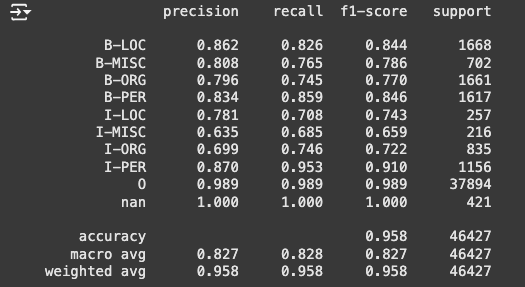

<br>

The model faces an imbalance issue, particularly with the I-MISC and I-LOC classes, as evidenced by the support column showing fewer samples for these categories. This imbalance negatively impacts performance, with the I-MISC class achieving a low F1-score of 0.66.

To address this, I applied class weights inversely proportional to class frequencies. Classes with higher appearances were assigned lower weights, while underrepresented classes received higher weights. After implementing this weighted approach, the imbalance issue was mitigated, leading to improved model performance across all classes.